# TD CUDA — Visualiser un objet SDF et projeter en 2D (affichage direct dans le notebook)

**But.** Je pars de la SDF fournie (un tore) et j’échantillonne un volume régulier dans \([-1,1]^3\). J’associe une couleur à chaque voxel selon l’orientation du gradient, noir si hors-objet. Ensuite, je projette ce volume en 2D sans perspective en parcourant chaque colonne \((x,z)\) le long de \(y\) et je conserve la **dernière** couleur non noire rencontrée.

**Colab / GPU.** J’utilise **Google Colab** en **mode GPU T4**  
(Runtime → Change runtime type → Hardware accelerator = **GPU**), ce qui me donne une **NVIDIA T4** et un environnement CUDA adapté.

**Affichage dans le notebook.** Je ne crée pas de fichiers. Le programme C++/CUDA écrit l’image **PPM** sur `stdout`, et je la lis depuis Python pour l’afficher directement. Je fournis deux sorties :
- **slice_mid** : tranche XZ au plan **Y=0** pour valider l’échantillonnage
- **projection** : image 2D finale après projection

**Organisation.**
1. Vérification GPU (T4)
2. Code complet `visu.cu` :
   - Mapping 3D→1D `idx(x,y,z) = x + size*(y + size*z)`
   - Allocation device + host
   - Kernel d’échantillonnage 3D
   - Kernel de projection sans perspective
   - Sortie PPM **en mémoire** vers `stdout` (P6 binaire) selon l’argument `slice` ou `proj`
3. Compilation
4. Exécution et **affichage inline** des deux images, sans fichiers
5. Récapitulatif


In [ ]:
!nvidia-smi


Thu Nov  6 21:38:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%writefile visu.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cstring>
#include <cuda_runtime.h>

// -----------------------------------------------------------------------------
// Types et utilitaires
// -----------------------------------------------------------------------------
typedef struct {
  unsigned char r;
  unsigned char g;
  unsigned char b;
} Color;

#ifdef __GNUC__
#define __UNUSED__ __attribute__((unused))
#endif

__device__ const double eps = 0.01;

__device__ double cudaAbs(double a) { return a >= 0 ? a : -a; }

__device__ void Translate(double * x, double * y, double * z,
                          double offsetX, double offsetY, double offsetZ) {
  *x -= offsetX; *y -= offsetY; *z -= offsetZ;
}

__device__ void Rotate(double * x, double * y, double * z,
                       double angleX, double angleY, double angleZ) {
  double tmpX, tmpY, tmpZ;
  if (angleX != 0) {
    float s, c; __sincosf(-angleX, &s, &c);
    tmpY = *y * c - *z * s;
    tmpZ = *y * s + *z * c;
    *y = tmpY; *z = tmpZ;
  }
  if (angleY != 0) {
    float s, c; __sincosf(-angleY, &s, &c);
    tmpX = *x * c + *z * s;
    tmpZ = -*x * s + *z * c;
    *x = tmpX; *z = tmpZ;
  }
  if (angleZ != 0) {
    float s, c; __sincosf(-angleZ, &s, &c);
    tmpX = *x * c - *y * s;
    tmpY = *x * s + *y * c;
    *x = tmpX; *y = tmpY;
  }
}

__device__ double SDF_torus(double x, double y, double z) {
  double sizeX = 0.5, sizeY = 0.2;
  double qx = __dsqrt_rn(x*x + z*z) - sizeX;
  double qy = y;
  return __dsqrt_rn(qx*qx + qy*qy) - sizeY;
}

__device__ double SDF(double x, double y, double z,
                      double posX, double posY, double posZ,
                      double rotX, double rotY, double rotZ) {
  Rotate(&x, &y, &z, rotX, rotY, rotZ);
  Translate(&x, &y, &z, posX, posY, posZ);
  return SDF_torus(x, y, z);
}

__device__ double GetDistance(double x, double y, double z) {
  // Paramètres conservés
  return SDF(x, y, z, 0, 0, 0, 45, 90, -5);
}

__device__ void GetColor(double x, double y, double z, Color * color) {
  double distance = GetDistance(x, y, z);
  if (distance > 0) { color->r=0; color->g=0; color->b=0; return; }

  double dx = distance - GetDistance(x + eps, y, z);
  double dy = distance - GetDistance(x, y + eps, z);
  double dz = distance - GetDistance(x, y, z + eps);

  double ax = cudaAbs(dx), ay = cudaAbs(dy), az = cudaAbs(dz);
  if (ax >= ay && ax >= az) {
    if (dx >= 0) { color->r=255; color->g=0;   color->b=0;   }
    else         { color->r=255; color->g=255; color->b=0;   }
  } else if (ay >= ax && ay >= az) {
    if (dy >= 0) { color->r=0;   color->g=255; color->b=0;   }
    else         { color->r=0;   color->g=255; color->b=255; }
  } else {
    if (dz >= 0) { color->r=0;   color->g=0;   color->b=255; }
    else         { color->r=255; color->g=0;   color->b=255; }
  }
}

// -----------------------------------------------------------------------------
// Mapping 3D → 1D demandé : idx(x,y,z) = x + size*(y + size*z)
// -----------------------------------------------------------------------------
__host__ __device__ inline size_t idx3D(int x, int y, int z, int size) {
  return (size_t)x + (size_t)size * ((size_t)y + (size_t)size * (size_t)z);
}

// -----------------------------------------------------------------------------
// Paramètres
// -----------------------------------------------------------------------------
struct Box { double xmin, ymin, zmin, xmax, ymax, zmax; };
struct Params { int size; Box box; };

// -----------------------------------------------------------------------------
// Kernel d’échantillonnage : un thread ↔ un voxel
// -----------------------------------------------------------------------------
__global__ void samplingKernel(Color * __restrict__ d_colors, Params p)
{
  int x = blockIdx.x * blockDim.x + threadIdx.x;
  int y = blockIdx.y * blockDim.y + threadIdx.y;
  int z = blockIdx.z * blockDim.z + threadIdx.z;
  if (x >= p.size || y >= p.size || z >= p.size) return;

  double sx = (double)x / (double)(p.size - 1);
  double sy = (double)y / (double)(p.size - 1);
  double sz = (double)z / (double)(p.size - 1);

  double X = p.box.xmin + (p.box.xmax - p.box.xmin) * sx;
  double Y = p.box.ymin + (p.box.ymax - p.box.ymin) * sy;
  double Z = p.box.zmin + (p.box.zmax - p.box.zmin) * sz;

  Color c; GetColor(X, Y, Z, &c);
  d_colors[idx3D(x, y, z, p.size)] = c;
}

// -----------------------------------------------------------------------------
// Kernel de projection : un thread ↔ une colonne (x,z), dernière couleur non noire
// -----------------------------------------------------------------------------
__global__ void projectionKernel(Color * __restrict__ d_colors, Params p)
{
  int x = blockIdx.x * blockDim.x + threadIdx.x;
  int z = blockIdx.y * blockDim.y + threadIdx.y;
  if (x >= p.size || z >= p.size) return;

  Color last = {0,0,0};
  for (int y = 0; y < p.size; ++y) {
    Color c = d_colors[idx3D(x, y, z, p.size)];
    if (!(c.r == 0 && c.g == 0 && c.b == 0)) last = c;
  }
  d_colors[idx3D(x, 0, z, p.size)] = last;
}

// -----------------------------------------------------------------------------
// Écriture PPM P6 (binaire) d’une tranche Y=slice depuis un tableau 3D hôte
// vers stdout (sans fichier). L’ordre est (x, slice, z).
// -----------------------------------------------------------------------------
static void WritePPMToStdout_SliceY(const Color *h_colors, int slice, int size) {
  // En-tête PPM P6
  std::printf("P6\n%d %d\n255\n", size, size);
  // Pixels : 3 octets par pixel, ordre (x,z)
  for (int x = 0; x < size; ++x) {
    for (int z = 0; z < size; ++z) {
      const Color &c = h_colors[idx3D(x, slice, z, size)];
      unsigned char rgb[3] = { c.r, c.g, c.b };
      std::fwrite(rgb, 1, 3, stdout);
    }
  }
}

// -----------------------------------------------------------------------------
// Programme principal
//   - argv[1] = "slice" → écrit la tranche XZ à Y=0 (y=size/2 dans la grille)
//   - argv[1] = "proj"  → écrit l’image projetée (contenue à y=0 après kernel)
// Par défaut, j’écris la tranche "slice".
// -----------------------------------------------------------------------------
int main(__UNUSED__ int argc, __UNUSED__ char **argv)
{
  const int size = 1000; // résolution demandée
  Params p; p.size = size; p.box = {-1, -1, -1, 1, 1, 1};

  // Allocation device + host
  size_t voxels  = (size_t)size * size * size;
  size_t bytes3D = voxels * sizeof(Color);

  Color *d_colors = nullptr;
  cudaError_t err = cudaMalloc((void**)&d_colors, bytes3D);
  if (err != cudaSuccess) {
    std::fprintf(stderr, "cudaMalloc failed: %s\n", cudaGetErrorString(err));
    return EXIT_FAILURE;
  }

  Color *h_colors = (Color*)std::malloc(bytes3D);
  if (!h_colors) {
    std::fprintf(stderr, "host malloc failed for %zu bytes\n", bytes3D);
    cudaFree(d_colors);
    return EXIT_FAILURE;
  }

  // Échantillonnage 3D
  dim3 block3d(8,8,8);
  dim3 grid3d((size + block3d.x - 1)/block3d.x,
              (size + block3d.y - 1)/block3d.y,
              (size + block3d.z - 1)/block3d.z);
  samplingKernel<<<grid3d, block3d>>>(d_colors, p);
  cudaDeviceSynchronize();

  // Variante de sortie
  bool wantProj = false;
  if (argc >= 2) {
    if (std::strcmp(argv[1], "proj") == 0) wantProj = true;
  }

  if (wantProj) {
    // Projection 2D : un thread par colonne (x,z), résultat écrit à y=0
    dim3 block2d(16,16,1);
    dim3 grid2d((size + block2d.x - 1)/block2d.x,
                (size + block2d.y - 1)/block2d.y,
                1);
    projectionKernel<<<grid2d, block2d>>>(d_colors, p);
    cudaDeviceSynchronize();

    // Copier tout vers l’hôte pour écrire la tranche y=0
    cudaMemcpy(h_colors, d_colors, bytes3D, cudaMemcpyDeviceToHost);
    WritePPMToStdout_SliceY(h_colors, /*slice y*/ 0, size);

  } else {
    // Tranche XZ au plan Y=0 → y ≈ size/2
    int yMid = size / 2;
    cudaMemcpy(h_colors, d_colors, bytes3D, cudaMemcpyDeviceToHost);
    WritePPMToStdout_SliceY(h_colors, yMid, size);
  }

  cudaFree(d_colors);
  std::free(h_colors);
  return 0;
}


Overwriting visu.cu


## Choix des grilles et blocs

**Échantillonnage 3D.** J’utilise des blocs `8×8×8` et une grille 3D `ceil(size/8)` par dimension. Un thread traite un voxel, ce qui colle naturellement à la topologie du volume et maintient une bonne occupation sur T4.

**Projection 2D.** Je lance une grille 2D avec des blocs `16×16` sur le plan `(x,z)`. Chaque thread parcourt sa colonne en `y` et conserve la dernière couleur non noire, qu’il écrit à `y=0`.


In [ ]:
!nvcc -O3 -arch=sm_75 visu.cu -o visu


## Tranche XZ au plan Y=0 (validation échantillonnage)

J’exécute `./visu slice` qui écrit une image **PPM P6** sur `stdout`. Je capture ces octets en Python, je les charge en mémoire et je les affiche dans le notebook.


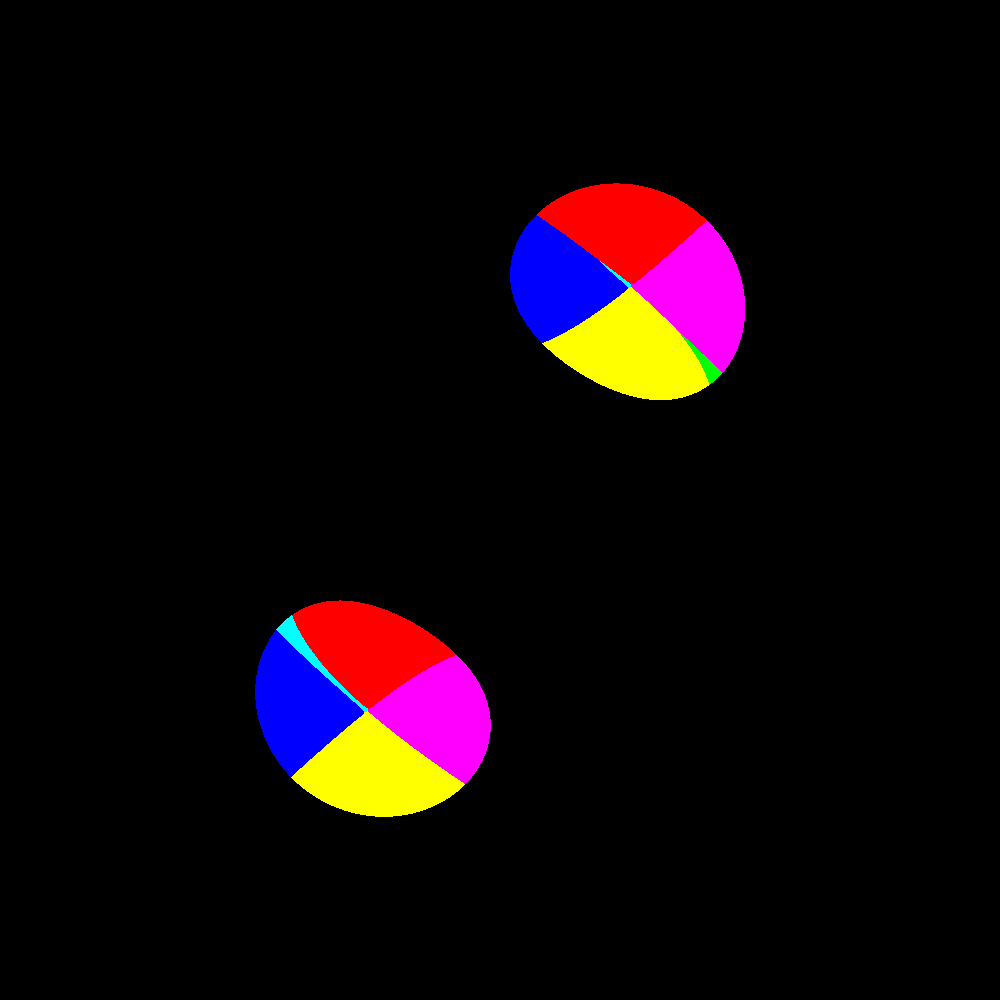

In [ ]:
import subprocess, io
from PIL import Image
from IPython.display import display

# Exécuter le binaire et capturer les octets PPM en mémoire
ppm_bytes_slice = subprocess.check_output(["./visu", "slice"])

# Charger l'image PPM depuis un flux mémoire et l'afficher
img_slice = Image.open(io.BytesIO(ppm_bytes_slice))
display(img_slice)


## Image projetée 2D (projection sans perspective)

J’exécute `./visu proj` qui écrit l’image projetée sur `stdout`. Même principe : je capture, je charge et j’affiche.


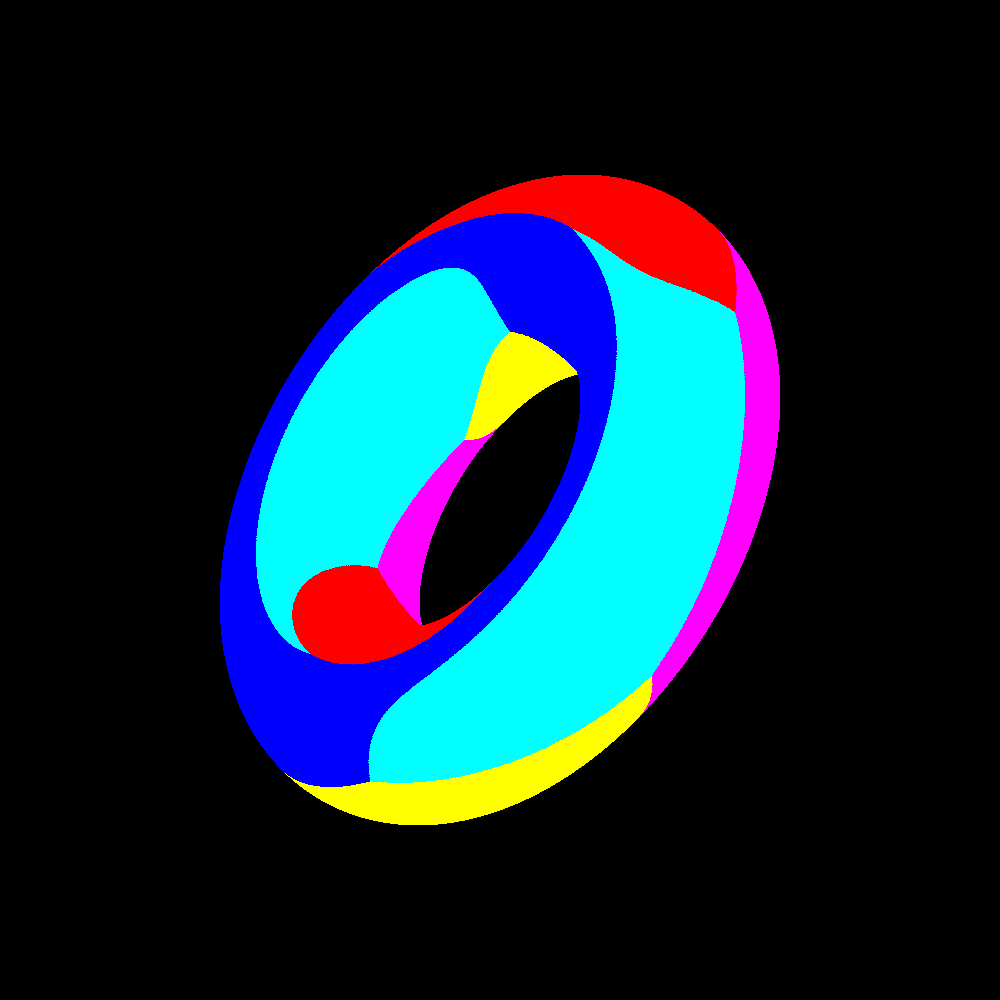

In [ ]:
import subprocess, io
from PIL import Image
from IPython.display import display

ppm_bytes_proj = subprocess.check_output(["./visu", "proj"])
img_proj = Image.open(io.BytesIO(ppm_bytes_proj))
display(img_proj)


## Récapitulatif par rapport au sujet

- **Q.1** Mapping 3D→1D : `idx(x,y,z) = x + size*(y + size*z)` et accès **(x, slice, z)** dans `PPMSave`.
- **Q.2** Allocations host et device d’un tableau 1D contigu de `Color`.
- **Q.3–Q.5** Kernel d’échantillonnage uniforme dans `[-1,1]^3`, validation par la tranche XZ au plan **Y=0** avec `yMid = size/2`.
- **Q.6–Q.7** Kernel de projection sans perspective, un thread par colonne `(x,z)`, écriture de la **dernière** couleur non noire à `y=0`, puis affichage final dans le notebook.
